# Training the Weight Autoencoder

We train a transformer VAE on ResNet-20 weight chunks with no bottleneck (`r = 1`) and KL
disabled (`beta = 0`), then check that the decoded weights still produce a working
classifier.

Compression and KL get turned on separately in the next stage, one at a time, so a failure
can always be traced to a single change.

Latent analysis and reconstruction helpers live in `latent_analysis.py`, `reconstruction.py`
and `cifar_eval_data.py`.

In [2]:
import os
import torch
import warnings
import chunking as C
from tqdm import tqdm
from pathlib import Path
from torch import nn, optim
from resnet20 import resnet20
import torch.nn.functional as F
import json, random, numpy as np
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR100
from transformer_vae import TVAE, vae_loss
from torch.utils.data import DataLoader, Dataset
from constants import SEED, device, TOKENS_PER_SEQ, IMG_PATH
from dataset import ResZoo, summon_res_zoo
warnings.filterwarnings("ignore")

## Load the data and data loaders

`train` is experts 0 to 2, `validation` is expert 3, `test` is expert 4 and stays
untouched until the end. `merge` holds the five final checkpoints, kept out of VAE
training so the encoder cannot have memorised the weights we later merge.

In [3]:
zoo_dir = './zoo_chunks'
training_set, validation_set, test_set, merge_set = summon_res_zoo('./zoo_chunks')
train_dataset = ResZoo(root_dir=zoo_dir, model_ids=training_set)
validation_dataset = ResZoo(root_dir=zoo_dir, model_ids=validation_set)
test_dataset = ResZoo(root_dir=zoo_dir, model_ids=test_set)
merge_dataset = ResZoo(root_dir=zoo_dir, model_ids=merge_set)

backbone_dataset = ResZoo(root_dir='./zoo_reference', model_ids=['backbone_a',])

print(f'train {len(training_set)}  val {len(validation_set)}  ', f'test {len(test_set)}  merge {len(merge_set)}')

train 27  val 9   test 10  merge 5


In [4]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
validation_loader = DataLoader(validation_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
merge_loader = DataLoader(merge_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

## Train the TVAE 
### STAGE A: BETA = 0

`latent_dim = 144` gives `r = 1`, and `BETA = 0.0` leaves it a plain autoencoder. The
point is to give the model every advantage: if reconstruction still breaks the ResNet,
the fault is in the plumbing rather than in compression.

Worth watching the train/val gap. Our 27 training checkpoints come from only three
fine-tuning trajectories, so the effective dataset is smaller than the sequence count
suggests.

In [5]:
tvae_model = TVAE(input_dim=144, model_dim=256, latent_dim=144).to(device)
tvae_model_path = './res_models/tvae_r1.pt'
trained = False
if os.path.exists(tvae_model_path):
    check_point = torch.load(tvae_model_path, weights_only=True)
    tvae_model.load_state_dict(check_point['state_dict'])
    trained = True

In [6]:
EPOCHS = 200
BETA = 0.0            

In [7]:
@torch.no_grad()
def eval_recon(model, loader, beta=0.0):
    '''eval mode makes reparameterize return mu, so reconstruction is deterministic'''
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        chunks = batch['chunks'].to(device, non_blocking=True)
        mask = batch['mask'].to(device, non_blocking=True)
        depth = batch['depth'].to(device, non_blocking=True)
        stage = batch['stage'].to(device, non_blocking=True)
        xhat, mu, logvar = model(chunks, depth, stage)
        _, recon, _ = vae_loss(xhat, chunks, mu, logvar, mask, beta)
        total += recon.item(); n += 1
    return total / max(n, 1)

In [8]:
def train_tvae(model, train_loader, validation_loader, lr = 1e-4, EPOCHS = EPOCHS, BETA = BETA, output_path = './res_models/tvae_r1.pt'):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    best_val = float('inf')
    for epoch in range(EPOCHS):
        model.train()
        running_recon, running_kl, n = 0.0, 0.0, 0

        for batch in train_loader:
            chunks = batch['chunks'].to(device, non_blocking=True)
            mask = batch['mask'].to(device, non_blocking=True)
            depth = batch['depth'].to(device, non_blocking=True)
            stage = batch['stage'].to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            '''forward returns three things, not one'''
            xhat, mu, logvar = model(chunks, depth, stage)
            loss, recon, kl = vae_loss(xhat, chunks, mu, logvar, mask, BETA)
            loss.backward()
            '''clip so a rare outlier chunk cannot blow up a step'''
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_recon += recon.item(); running_kl += kl.item(); n += 1

        scheduler.step()

        if (epoch + 1) % 5 == 0 or epoch == 0:
            val_recon = eval_recon(model, validation_loader, BETA)
            print(f'epoch {epoch+1:3d}/{EPOCHS}  train recon {running_recon/n:.5f}  '
                f'val recon {val_recon:.5f}  kl {running_kl/n:.2f}  '
                f'lr {scheduler.get_last_lr()[0]:.2e}')

            if val_recon < best_val:
                best_val = val_recon
                torch.save({
                    'state_dict': model.state_dict(),
                    'epoch': epoch + 1,
                    'val_recon': val_recon,
                    'latent_dim': model.latent_dim,
                    'beta': BETA,
                }, output_path)

    print(f'done, best val recon {best_val:.5f}')


if not trained:
    train_tvae(tvae_model, train_loader, validation_loader, EPOCHS = EPOCHS, BETA = BETA, output_path = './res_models/tvae_r1.pt')


## Latent space analysis (BETA = 0)

t-SNE grids per depth, plus two distance metrics. `expert_separation` is the number to
trust: t-SNE exaggerates separation on few points, the ratio is computed on the raw
latents.

Reusable across beta values, just reload `tvae_model` and rerun.

In [9]:
from latent_analysis import (BACKBONE_LABEL, build_latents, plot_depth_grid, expert_separation, backbone_distance)

latents (4403, 16, 144)  labels [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]  (-1 = backbone)


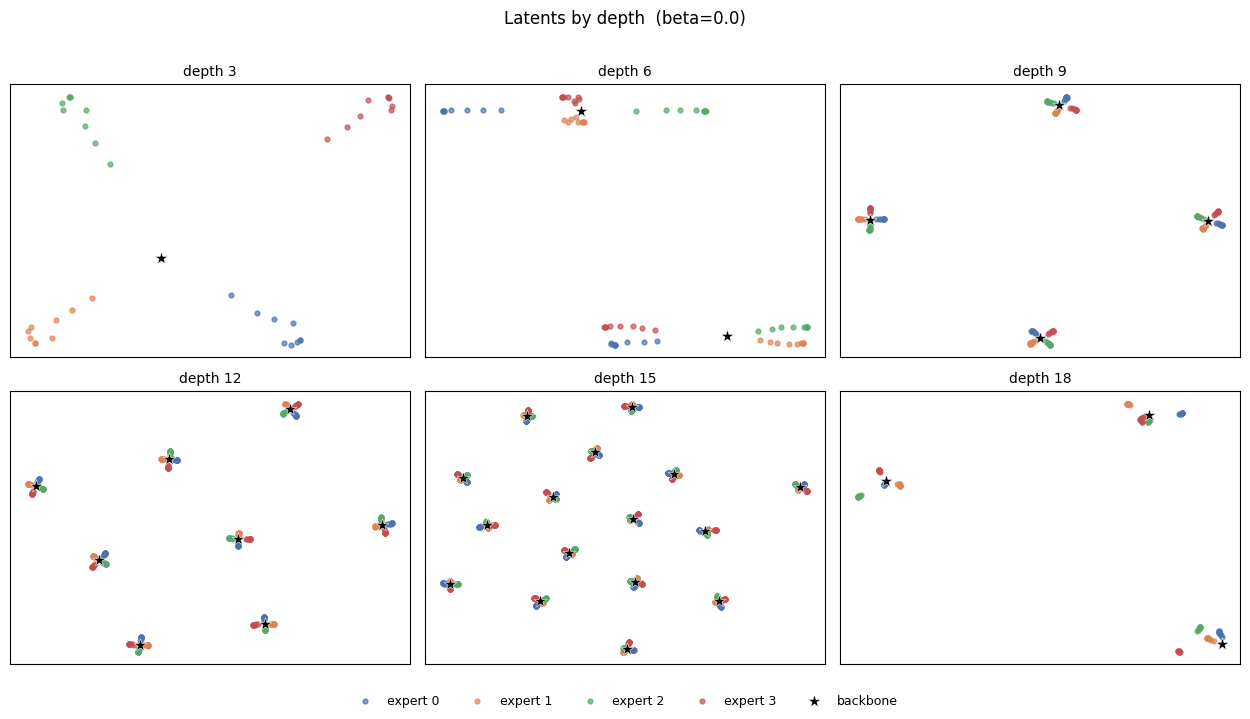


depth  3: within    2.469  between    7.701  ratio 3.120
depth  6: within   24.083  between   24.732  ratio 1.027
depth  9: within   36.646  between   37.265  ratio 1.017
depth 12: within   41.157  between   41.356  ratio 1.005
depth 15: within   43.430  between   43.559  ratio 1.003
depth 18: within   30.362  between   30.144  ratio 0.993

depth  3: backbone to experts e0=  5.310  e1=  5.102  e2=  5.663  e3=  5.810
depth  6: backbone to experts e0= 23.891  e1= 23.803  e2= 23.907  e3= 23.966
depth  9: backbone to experts e0= 36.604  e1= 36.424  e2= 36.582  e3= 36.742
depth 12: backbone to experts e0= 41.103  e1= 41.013  e2= 41.034  e3= 41.102
depth 15: backbone to experts e0= 43.378  e1= 43.361  e2= 43.365  e3= 43.399
depth 18: backbone to experts e0= 29.807  e1= 29.835  e2= 29.818  e3= 29.858


[(3,
  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
  [np.float32(5.3096137),
   np.float32(5.1020985),
   np.float32(5.6629777),
   np.float32(5.809836)]),
 (6,
  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
  [np.float32(23.891224),
   np.float32(23.803274),
   np.float32(23.906843),
   np.float32(23.966301)]),
 (9,
  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
  [np.float32(36.604153),
   np.float32(36.42385),
   np.float32(36.58159),
   np.float32(36.74163)]),
 (12,
  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
  [np.float32(41.102844),
   np.float32(41.01292),
   np.float32(41.034206),
   np.float32(41.10232)]),
 (15,
  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
  [np.float32(43.377872),
   np.float32(43.36055),
   np.float32(43.365448),
   np.float32(43.39905)]),
 (18,
  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
  [np.float32(29.80678),
   np.float32(29.835335),
   np.float32(29.817509),
   np.float32(29.858223)])]

In [10]:
BETA = 0.0

ALL_DEPTHS = list(range(3,19,3))

lat, depths, stages, splits = build_latents(
    tvae_model, zoo_dir, training_set + validation_set,
    reference_dir='./zoo_reference', reference_ids=['backbone_a'])

print(f'latents {lat.shape}  labels {sorted(set(splits))}  '
     f'({BACKBONE_LABEL} = backbone)')

plot_depth_grid(lat, depths, splits, ALL_DEPTHS, n_cols=3,
                tag=f'  (beta={BETA})', savepath=os.path.join(IMG_PATH, f'latent_grid_beta{BETA}.png'))

print()
expert_separation(lat, depths, splits, ALL_DEPTHS)
print()
backbone_distance(lat, depths, splits, ALL_DEPTHS)

## Reconstruction check

Low reconstruction loss is not enough. MSE averages over 274k weights and can look fine
while the decoder quietly smooths away the few that matter, so we load the decoded weights
back into a ResNet and measure accuracy.

BatchNorm running stats have to be reset and recalibrated first. They are properties of the
weights and data together and are invalid after any weight change.

Own-group accuracy is the number to read. `all` is dominated by the 80 classes where the
expert is already near chance, so it hides damage.

In [11]:
from reconstruction import reconstruct_model, evaluate_grouped, evaluate_reconstruction
from cifar_eval_data import load_cifar_eval

(train_dataset_cifar, test_dataset_cifar, full_test_loader, zoo_train_feed, zoo_test_feed) = load_cifar_eval('./res_data/')

In [12]:
'''expert 3 is the VAE validation model, evaluated on the CIFAR-100 test set'''
EXPERT_ID = 3
MODEL_ID = 'split3_seed1246_ep40'

ds_one = ResZoo(root_dir=zoo_dir, model_ids=[MODEL_ID])
loader_one = DataLoader(ds_one, batch_size=64, shuffle=False)

ck = torch.load('res_models/expert3_seed1246/ep040.pt', map_location='cpu')
sd_hat = reconstruct_model(tvae_model, loader_one, ds_one, ck['state_dict'])

'''recalibrate on the expert's own training subset, that is the distribution it saw'''
recal_subset = torch.utils.data.Subset(train_dataset_cifar, zoo_train_feed[EXPERT_ID])
recal_loader = DataLoader(recal_subset, batch_size=128, shuffle=True, num_workers=2)

evaluate_reconstruction(sd_hat, ck['state_dict'], EXPERT_ID, recal_loader, full_test_loader)

                   own   other     all
original         83.60    6.25   21.72
reconstructed    83.30    9.04   23.89
delta            -0.30    2.79    2.17

  worst rel err  layer3.1.conv1.weight      0.1094
  worst rel err  layer3.0.conv2.weight      0.1077
  worst rel err  layer2.1.conv2.weight      0.1032
  worst rel err  layer2.0.conv2.weight      0.1012
  worst rel err  layer3.1.conv2.weight      0.0955

  index 1249 of layer1.2.conv2: original -0.6102  reconstructed -0.5705


2.1700000000000017

## STAGE B: 
Try different BETAs = [1e-6, 1e-5, 1e-4]

In [12]:
check_point = torch.load(tvae_model_path, weights_only=True)
tvae_model.load_state_dict(check_point['state_dict'])

<All keys matched successfully>

In [14]:
BETAs = [1e-6, 1e-5, 1e-4]

for BETA in BETAs:
    print(f'BETA: {BETA}')
    tvae_model.load_state_dict(torch.load(tvae_model_path, weights_only=True)['state_dict'])
    train_tvae(tvae_model, train_loader, validation_loader, lr=1e-4, EPOCHS=50, BETA=BETA, output_path=f'./res_models/tvae_r1_beta{BETA}.pt')

BETA: 1e-06


epoch   1/50  train recon 0.00677  val recon 0.00265  kl 681.29  lr 9.99e-05
epoch   5/50  train recon 0.00102  val recon 0.00227  kl 637.94  lr 9.76e-05
epoch  10/50  train recon 0.00089  val recon 0.00226  kl 632.47  lr 9.05e-05
epoch  15/50  train recon 0.00076  val recon 0.00214  kl 628.94  lr 7.94e-05
epoch  20/50  train recon 0.00063  val recon 0.00197  kl 627.84  lr 6.55e-05
epoch  25/50  train recon 0.00056  val recon 0.00187  kl 626.45  lr 5.00e-05
epoch  30/50  train recon 0.00053  val recon 0.00183  kl 625.51  lr 3.45e-05
epoch  35/50  train recon 0.00050  val recon 0.00179  kl 625.25  lr 2.06e-05
epoch  40/50  train recon 0.00048  val recon 0.00177  kl 624.88  lr 9.55e-06
epoch  45/50  train recon 0.00047  val recon 0.00176  kl 624.94  lr 2.45e-06
epoch  50/50  train recon 0.00047  val recon 0.00176  kl 624.85  lr 0.00e+00
done, best val recon 0.00176
BETA: 1e-05
epoch   1/50  train recon 0.00703  val recon 0.00280  kl 515.10  lr 9.99e-05
epoch   5/50  train recon 0.00160  

## Latent space analysis (BETA = 0)


In [21]:
from latent_analysis import collect_latents_sampled, plot_overlap_grid, posterior_overlap
ds = ResZoo(root_dir=zoo_dir, model_ids=training_set + validation_set)

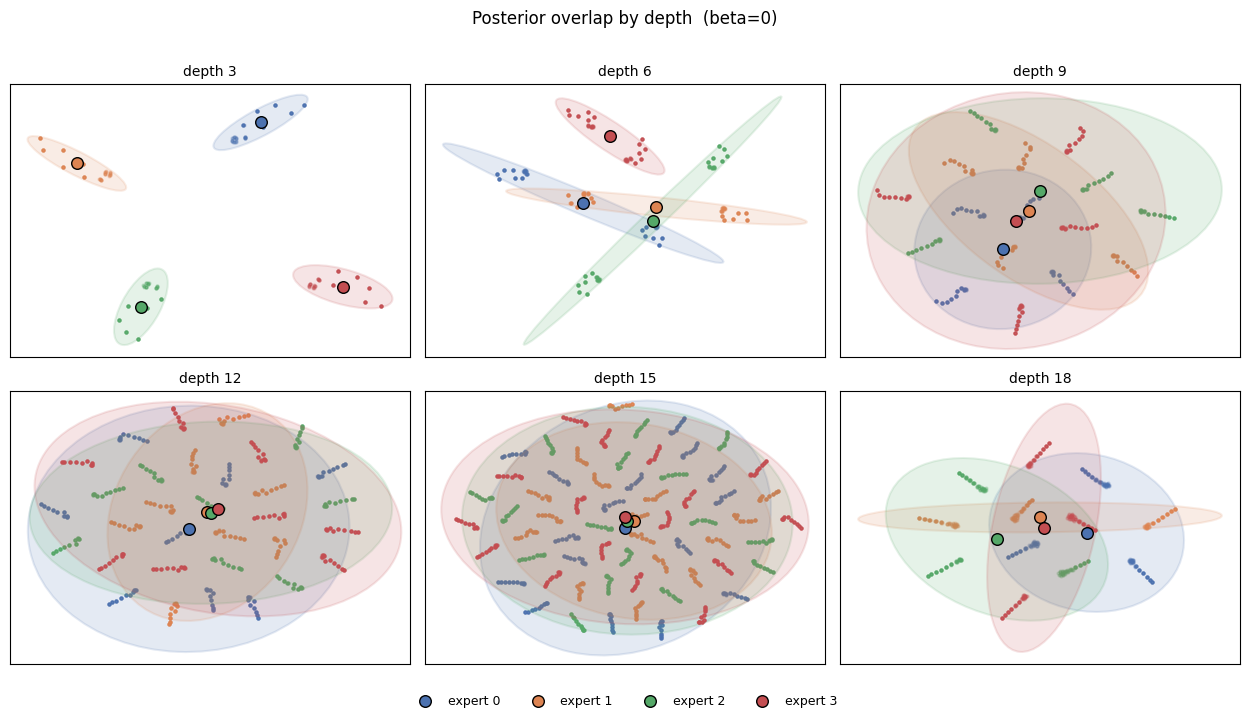

depth  3: between-expert    7.241  posterior sigma    0.171  ratio 42.270
depth  6: between-expert    3.811  posterior sigma    0.165  ratio 23.153
depth  9: between-expert    4.205  posterior sigma    0.142  ratio 29.509
depth 12: between-expert    2.814  posterior sigma    0.103  ratio 27.227
depth 15: between-expert    2.114  posterior sigma    0.121  ratio 17.471
depth 18: between-expert    1.606  posterior sigma    0.171  ratio 9.393


[(3, np.float32(7.2407403), np.float32(0.1712993), np.float32(42.269527)),
 (6, np.float32(3.8107936), np.float32(0.16459394), np.float32(23.152699)),
 (9, np.float32(4.204557), np.float32(0.14248234), np.float32(29.50932)),
 (12, np.float32(2.814476), np.float32(0.103371784), np.float32(27.226734)),
 (15, np.float32(2.1138124), np.float32(0.120989), np.float32(17.471113)),
 (18, np.float32(1.6060448), np.float32(0.17098045), np.float32(9.393148))]

In [23]:
BETA = 0
tvae_model.load_state_dict(torch.load(f'./res_models/tvae_r1.pt', weights_only=True)['state_dict'])
lat_s, depths_s, midx_s = collect_latents_sampled(tvae_model, ds, n_samples=8)
splits_s = np.array([int(ds.meta_list[m].split_id) for m in midx_s])

plot_overlap_grid(lat_s, depths_s, splits_s, ALL_DEPTHS, tag=f'  (beta={BETA})', savepath=os.path.join(IMG_PATH, f'overlap_beta{BETA}.png'))

posterior_overlap(tvae_model, ds, ALL_DEPTHS)

## Latent space analysis (BETA =1e-6 )

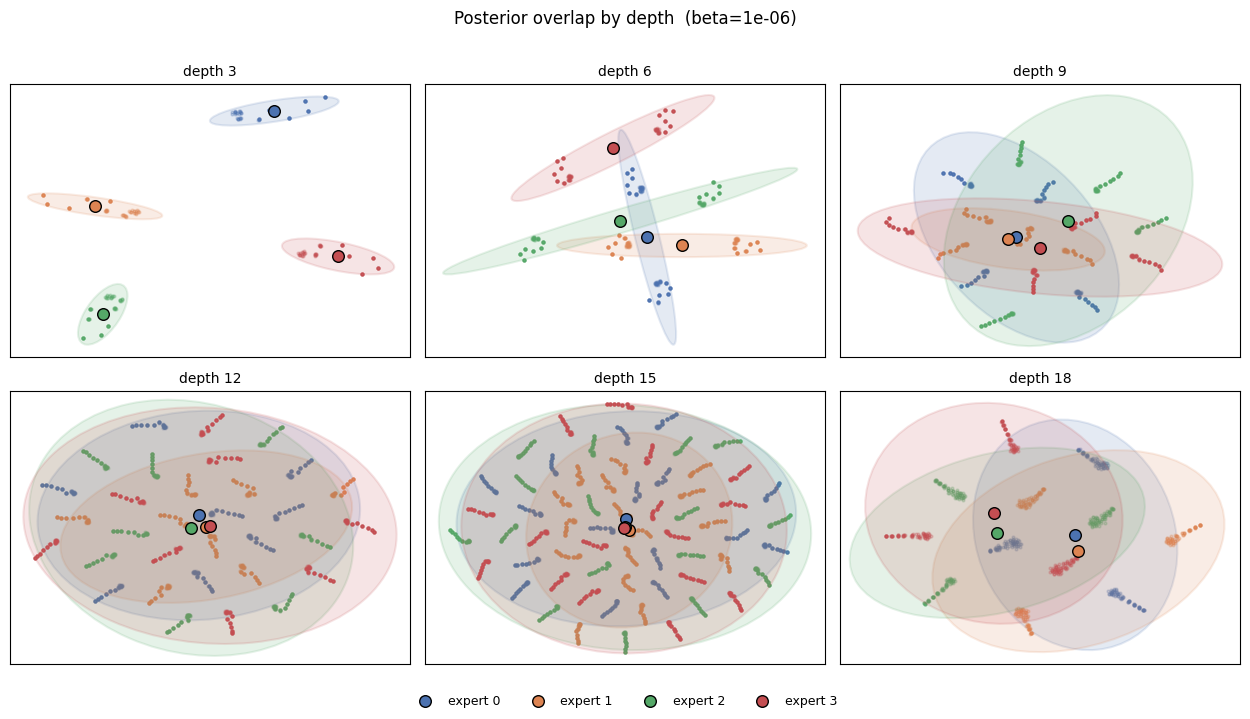

depth  3: between-expert    8.297  posterior sigma    0.629  ratio 13.182
depth  6: between-expert    4.371  posterior sigma    0.586  ratio 7.464
depth  9: between-expert    4.863  posterior sigma    0.562  ratio 8.647
depth 12: between-expert    3.341  posterior sigma    0.583  ratio 5.732
depth 15: between-expert    2.482  posterior sigma    0.547  ratio 4.540
depth 18: between-expert    1.793  posterior sigma    0.567  ratio 3.163


[(3, np.float32(8.297006), np.float32(0.62939864), np.float32(13.182433)),
 (6, np.float32(4.3706965), np.float32(0.5855792), np.float32(7.4638863)),
 (9, np.float32(4.86291), np.float32(0.5623878), np.float32(8.646897)),
 (12, np.float32(3.3412006), np.float32(0.58293), np.float32(5.731735)),
 (15, np.float32(2.481849), np.float32(0.54663587), np.float32(4.5402236)),
 (18, np.float32(1.7928206), np.float32(0.5668467), np.float32(3.162796))]

In [ ]:
BETA = 1e-6
tvae_model.load_state_dict(torch.load(f'./res_models/tvae_r1_beta{BETA}.pt', weights_only=True)['state_dict'])
lat_s, depths_s, midx_s = collect_latents_sampled(tvae_model, ds, n_samples=8)
splits_s = np.array([int(ds.meta_list[m].split_id) for m in midx_s])

plot_overlap_grid(lat_s, depths_s, splits_s, ALL_DEPTHS, tag=f'  (beta={BETA})', savepath=os.path.join(IMG_PATH, f'overlap_beta{BETA}.png'))

posterior_overlap(tvae_model, ds, ALL_DEPTHS)

## Latent space analysis (BETA =1e-5 )

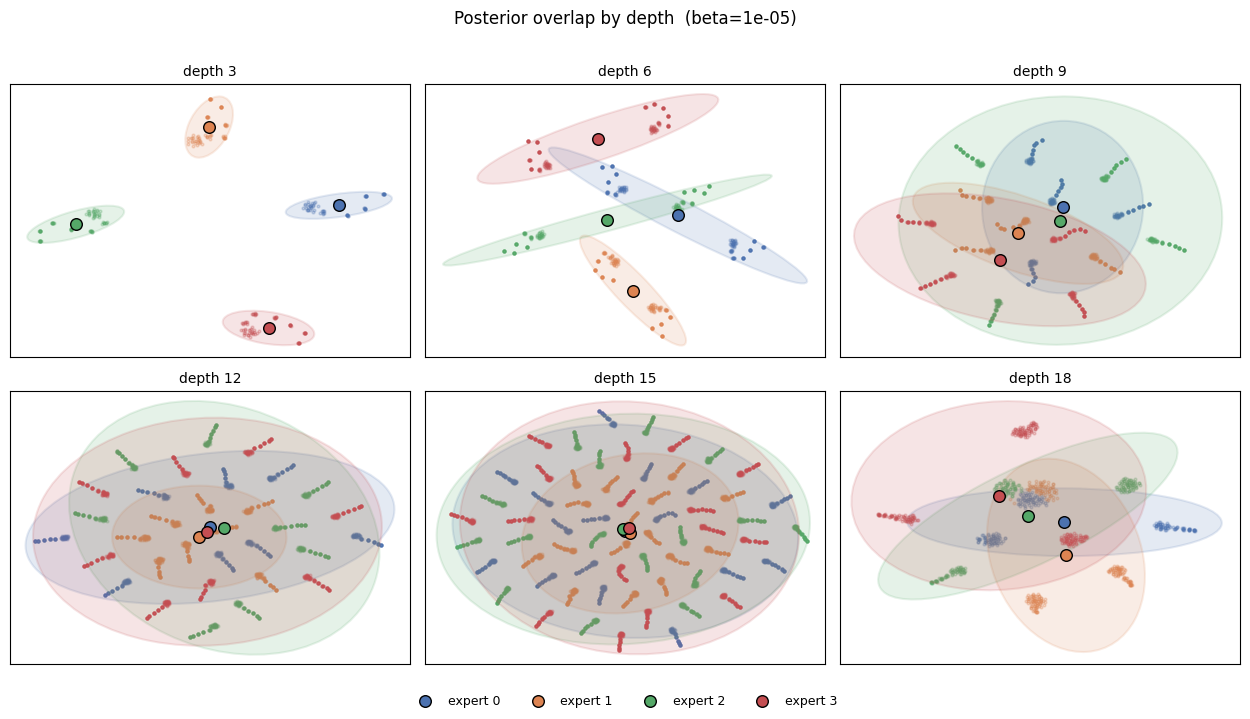

depth  3: between-expert    9.178  posterior sigma    2.238  ratio 4.102
depth  6: between-expert    4.853  posterior sigma    2.114  ratio 2.295
depth  9: between-expert    5.400  posterior sigma    2.090  ratio 2.583
depth 12: between-expert    3.754  posterior sigma    2.256  ratio 1.664
depth 15: between-expert    2.754  posterior sigma    2.060  ratio 1.337
depth 18: between-expert    1.944  posterior sigma    2.262  ratio 0.860


[(3, np.float32(9.177921), np.float32(2.2376506), np.float32(4.1015882)),
 (6, np.float32(4.852656), np.float32(2.1141984), np.float32(2.2952697)),
 (9, np.float32(5.399634), np.float32(2.090057), np.float32(2.5834866)),
 (12, np.float32(3.7542727), np.float32(2.2558475), np.float32(1.6642405)),
 (15, np.float32(2.753708), np.float32(2.0600264), np.float32(1.3367343)),
 (18, np.float32(1.9439163), np.float32(2.2616386), np.float32(0.85951674))]

In [25]:
BETA = 1e-5
tvae_model.load_state_dict(torch.load(f'./res_models/tvae_r1_beta{BETA}.pt', weights_only=True)['state_dict'])
lat_s, depths_s, midx_s = collect_latents_sampled(tvae_model, ds, n_samples=8)
splits_s = np.array([int(ds.meta_list[m].split_id) for m in midx_s])

plot_overlap_grid(lat_s, depths_s, splits_s, ALL_DEPTHS, tag=f'  (beta={BETA})', savepath=os.path.join(IMG_PATH, f'overlap_beta{BETA}.png'))

posterior_overlap(tvae_model, ds, ALL_DEPTHS)

## Latent space analysis (BETA =1e-4 )

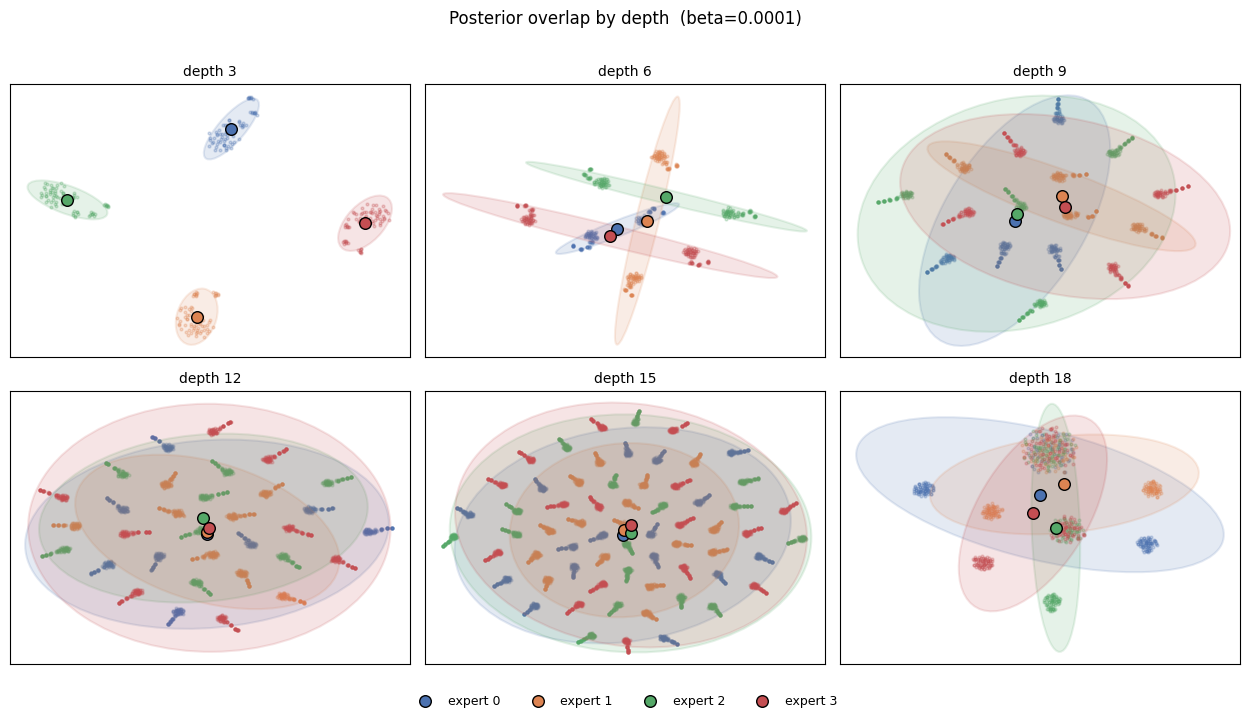

depth  3: between-expert   10.422  posterior sigma    9.167  ratio 1.137
depth  6: between-expert    5.567  posterior sigma    8.670  ratio 0.642
depth  9: between-expert    5.951  posterior sigma    8.292  ratio 0.718
depth 12: between-expert    4.175  posterior sigma    8.967  ratio 0.466
depth 15: between-expert    3.025  posterior sigma    8.064  ratio 0.375
depth 18: between-expert    2.124  posterior sigma   12.065  ratio 0.176


[(3, np.float32(10.422441), np.float32(9.16726), np.float32(1.1369199)),
 (6, np.float32(5.5669007), np.float32(8.670452), np.float32(0.64205426)),
 (9, np.float32(5.951178), np.float32(8.291679), np.float32(0.7177289)),
 (12, np.float32(4.174562), np.float32(8.967244), np.float32(0.46553454)),
 (15, np.float32(3.0254595), np.float32(8.0642395), np.float32(0.37516984)),
 (18, np.float32(2.123826), np.float32(12.064942), np.float32(0.17603284))]

In [ ]:
BETA = 1e-4
tvae_model.load_state_dict(torch.load(f'./res_models/tvae_r1_beta{BETA}.pt', weights_only=True)['state_dict'])
lat_s, depths_s, midx_s = collect_latents_sampled(tvae_model, ds, n_samples=8)
splits_s = np.array([int(ds.meta_list[m].split_id) for m in midx_s])

plot_overlap_grid(lat_s, depths_s, splits_s, ALL_DEPTHS, tag=f'  (beta={BETA})', savepath=os.path.join(IMG_PATH, f'overlap_beta{BETA}.png'))

posterior_overlap(tvae_model, ds, ALL_DEPTHS)